# 第五讲：灰色关联、PCA、因子分析与模糊综合评价

本 Notebook 使用一份城市评价数据，整理四类常用评价模型：灰色关联分析、PCA、因子分析和模糊综合评价。

这些模型并不是为了简单叠加，而是从不同角度回答评价问题：灰色关联强调与理想方案的接近程度，PCA 强调信息压缩，因子分析强调潜在结构，模糊综合评价强调等级边界不清时的综合判断。

## 0. 导入库与读取数据

数学建模中的评价模型通常从一张“评价对象 × 指标”的数据表开始。

本案例把 10 个城市作为评价对象，指标包括经济、公共服务和环境相关变量。注意：污染指数是成本型指标，数值越小越好。

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'Arial Unicode MS']
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('第五讲示例数据.csv')
OUT_DIR = Path('第五讲_outputs')
OUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df

,城市,人均GDP,居民收入,消费水平,教育投入,医疗资源,公共服务,绿化率,空气质量,污染指数
0,城市A,11.21,5.74,65.43,48.67,43.74,68.93,52.24,79.09,57.91
1,城市B,14.80,7.51,76.05,48.75,42.38,67.69,42.50,69.23,70.05
2,城市C,18.54,9.37,87.33,60.82,54.32,79.07,39.64,64.97,75.14
3,城市D,13.25,6.61,72.72,61.58,57.88,82.08,46.56,72.48,65.16
4,城市E,16.61,8.58,80.94,53.06,46.34,72.00,55.32,80.54,57.35
5,城市F,11.94,6.02,68.44,55.11,51.04,75.70,49.72,76.14,61.05
6,城市G,19.69,9.96,90.57,57.73,50.38,75.43,36.96,62.43,78.51
7,城市H,15.65,7.86,79.48,64.22,59.66,83.94,45.44,70.76,67.58
8,城市I,10.56,5.45,63.52,44.48,39.46,65.02,56.16,83.16,53.34
9,城市J,17.72,8.96,85.04,61.37,55.35,80.03,42.12,67.42,72.10


## 1. 指标同向化与标准化

在评价模型中，不同指标的单位和方向通常不同。

- **效益型指标**：越大越好，例如人均 GDP、居民收入、绿化率；
- **成本型指标**：越小越好，例如污染指数。

如果不先统一方向，后续灰色关联、PCA、因子分析和模糊评价都会出现解释错误。

In [2]:
benefit_cols = ['人均GDP', '居民收入', '消费水平', '教育投入', '医疗资源', '公共服务', '绿化率', '空气质量']
cost_cols = ['污染指数']
all_cols = benefit_cols + cost_cols

df_pos = df.copy()
# 成本型指标转为“越大越好”
for col in cost_cols:
    df_pos[col] = df_pos[col].max() - df_pos[col]

# Min-Max 标准化到 [0, 1]
df_norm = df_pos.copy()
for col in all_cols:
    df_norm[col] = (df_pos[col] - df_pos[col].min()) / (df_pos[col].max() - df_pos[col].min())

df_norm[['城市'] + all_cols]

,城市,人均GDP,居民收入,消费水平,教育投入,医疗资源,公共服务,绿化率,空气质量,污染指数
0,城市A,0.071194,0.064302,0.070610,0.212259,0.211881,0.206660,0.795833,0.803666,0.818435
1,城市B,0.464403,0.456763,0.463216,0.216312,0.144554,0.141121,0.288542,0.328027,0.336114
2,城市C,0.874042,0.869180,0.880222,0.827761,0.735644,0.742600,0.139583,0.122528,0.133890
3,城市D,0.294633,0.257206,0.340111,0.866261,0.911881,0.901691,0.500000,0.484805,0.530393
4,城市E,0.662651,0.694013,0.643993,0.434650,0.340594,0.368922,0.956250,0.873613,0.840683
5,城市F,0.151150,0.126386,0.181885,0.538501,0.573267,0.564482,0.664583,0.661360,0.693683
6,城市G,1.000000,1.000000,1.000000,0.671226,0.540594,0.550211,0.000000,0.000000,0.000000
7,城市H,0.557503,0.534368,0.590018,1.000000,1.000000,1.000000,0.441667,0.401833,0.434247
8,城市I,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
9,城市J,0.784228,0.778271,0.795564,0.855623,0.786634,0.793340,0.268750,0.240714,0.254668


## 2. 灰色关联分析（GRA）

灰色关联分析衡量比较序列与参考序列的接近程度。

设参考序列为最优序列：

$$X_0=(1,1,\\ldots2,1)$$

比较序列为各城市的标准化指标向量：

$$X_i=(x_i(1),x_i(2),\\ldots2,x_i(n))$$

绝对差：

$$\Delta_i(k)=|X_0(k)-X_i(k)|$$

关联系数：

$$\xi_i(k)=\frac{\Delta_{\min}+\rho\Delta_{\max}}{\Delta_i(k)+\rho\Delta_{\max}}$$

关联度：

$$r_i=\frac{1}{n}\sum_{k=1}^n \xi_i(k)$$

其中 $\rho$ 为分辨系数，通常取 0.5。

In [ ]:
rho = 0.5
X = df_norm[all_cols].values
X0 = np.ones(X.shape[1])
delta = np.abs(X0 - X)
delta_min = delta.min()
delta_max = delta.max()
coef = (delta_min + rho * delta_max) / (delta + rho * delta_max)
gra_score = coef.mean(axis=1)

gra_result = pd.DataFrame({'城市': df['城市'], '灰色关联度': gra_score})
gra_result['GRA排名'] = gra_result['灰色关联度'].rank(ascending=False, method='min').astype(int)
gra_result = gra_result.sort_values('GRA排名')
gra_result

,城市,灰色关联度,GRA排名
7,城市H,0.666073,1
6,城市G,0.627877,2
4,城市E,0.624484,3
2,城市C,0.616971,4
9,城市J,0.610017,5
3,城市D,0.581247,6
8,城市I,0.555556,7
10,城市K,0.542070,8
11,城市L,0.519773,9
5,城市F,0.502538,10


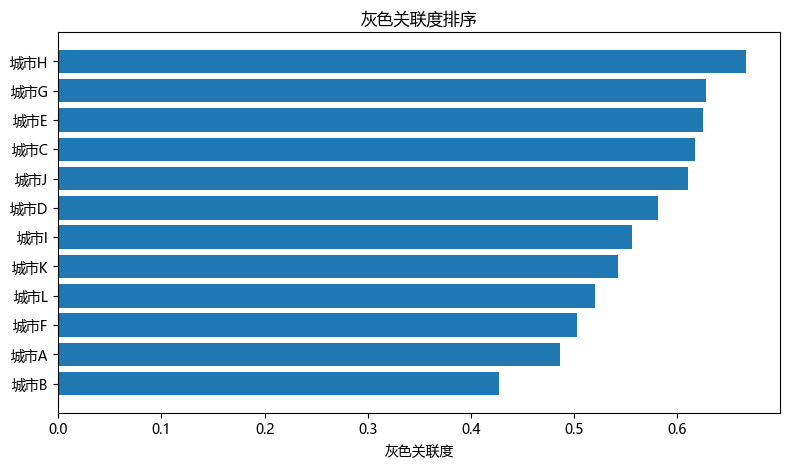

In [4]:
plt.figure(figsize=(8, 4.8))
plt.barh(gra_result['城市'][::-1], gra_result['灰色关联度'][::-1])
plt.xlabel('灰色关联度')
plt.title('灰色关联度排序')
plt.tight_layout()
plt.savefig(OUT_DIR / '01_灰色关联度排序.png', dpi=180)
plt.show()

## 3. PCA 主成分分析

PCA 的目标是寻找最大方差方向，把多个相关指标压缩成少数几个综合变量。

标准化数据矩阵记为 $Z$，相关矩阵为：

$$R=\frac{1}{n-1}Z^TZ$$

特征值分解：

$$Rv_k=\lambda_k v_k$$

贡献率：

$$\eta_k=\frac{\lambda_k}{\sum_j \lambda_j}$$

综合得分可写成：

$$Score_i=\sum_{k=1}^{m}\eta_k F_{ik}$$

In [5]:
Z = StandardScaler().fit_transform(df_pos[all_cols])
pca = PCA()
F = pca.fit_transform(Z)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

pca_table = pd.DataFrame({
    '主成分': [f'PC{i+1}' for i in range(len(explained))],
    '贡献率': explained,
    '累计贡献率': cum_explained
})
pca_table

,主成分,贡献率,累计贡献率
0,PC1,7.366728e-01,0.736673
1,PC2,1.903451e-01,0.927018
2,PC3,7.293822e-02,0.999956
3,PC4,4.359788e-05,1.000000
4,PC5,2.384293e-07,1.000000
5,PC6,1.353297e-08,1.000000
6,PC7,7.316575e-10,1.000000
7,PC8,3.094891e-32,1.000000
8,PC9,2.483031e-33,1.000000


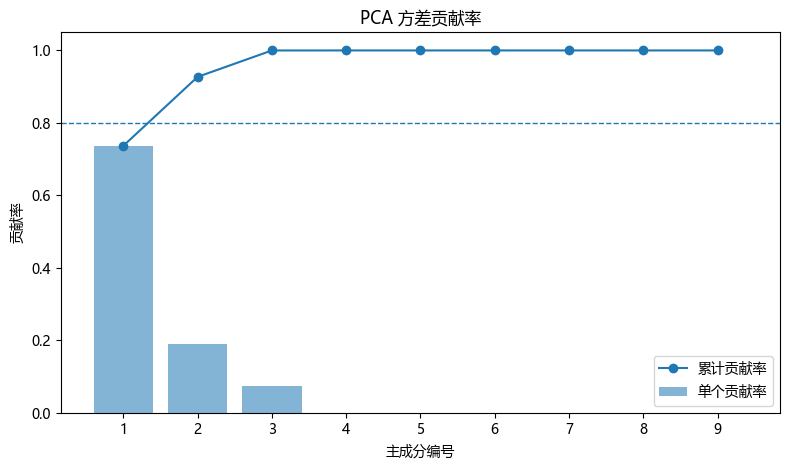

In [6]:
plt.figure(figsize=(8, 4.8))
plt.plot(range(1, len(explained)+1), cum_explained, marker='o', label='累计贡献率')
plt.bar(range(1, len(explained)+1), explained, alpha=0.55, label='单个贡献率')
plt.axhline(0.8, linestyle='--', linewidth=1)
plt.xticks(range(1, len(explained)+1))
plt.xlabel('主成分编号')
plt.ylabel('贡献率')
plt.title('PCA 方差贡献率')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '02_PCA方差贡献率.png', dpi=180)
plt.show()

In [7]:
m = np.argmax(cum_explained >= 0.8) + 1
pca_score = (F[:, :m] * explained[:m]).sum(axis=1) / explained[:m].sum()
pca_result = pd.DataFrame({'城市': df['城市'], 'PCA综合得分': pca_score})
pca_result['PCA排名'] = pca_result['PCA综合得分'].rank(ascending=False, method='min').astype(int)
pca_result.sort_values('PCA排名')

,城市,PCA综合得分,PCA排名
8,城市I,3.808831,1
0,城市A,2.686881,2
5,城市F,1.524547,3
10,城市K,0.965431,4
4,城市E,0.797273,5
3,城市D,0.075211,6
1,城市B,-0.070689,7
11,城市L,-0.251591,8
7,城市H,-1.168721,9
9,城市J,-2.185171,10


## 4. 因子分析：从“压缩指标”到“解释潜在结构”

因子分析假设多个观测变量受少数公共因子影响：

$$X=\Lambda F+\epsilon$$

其中：

- $X$：观测变量；
- $F$：公共因子；
- $\Lambda$：因子载荷矩阵；
- $\epsilon$：特殊因子或误差。

单个变量可以写成：

$$X_i=\lambda_{i1}F_1+\lambda_{i2}F_2+\cdots+\lambda_{im}F_m+\epsilon_i$$

因子分析的重点不是简单排名，而是解释“哪些指标属于同一个潜在维度”。

### 4.1 计算相关矩阵并判断是否适合因子分析

因子分析要求指标之间存在一定相关性。如果所有指标几乎互不相关，就很难提取公共因子。

In [8]:
corr = pd.DataFrame(Z, columns=all_cols).corr()
corr.round(3)

,人均GDP,居民收入,消费水平,教育投入,医疗资源,公共服务,绿化率,空气质量,污染指数
人均GDP,1.000,0.999,0.998,0.578,0.420,0.442,-0.738,-0.788,-0.819
居民收入,0.999,1.000,0.995,0.546,0.383,0.407,-0.711,-0.761,-0.795
消费水平,0.998,0.995,1.000,0.620,0.467,0.488,-0.756,-0.806,-0.834
教育投入,0.578,0.546,0.620,1.000,0.983,0.987,-0.580,-0.634,-0.612
医疗资源,0.420,0.383,0.467,0.983,1.000,0.999,-0.482,-0.531,-0.498
公共服务,0.442,0.407,0.488,0.987,0.999,1.000,-0.481,-0.532,-0.502
绿化率,-0.738,-0.711,-0.756,-0.580,-0.482,-0.481,1.000,0.996,0.992
空气质量,-0.788,-0.761,-0.806,-0.634,-0.531,-0.532,0.996,1.000,0.998
污染指数,-0.819,-0.795,-0.834,-0.612,-0.498,-0.502,0.992,0.998,1.000


### 4.2 提取公共因子

这份示例数据包含三个相对清楚的潜在维度：经济发展、公共服务和生态环境。因此这里提取 3 个因子。实际论文中，应结合特征值、累计贡献率、碎石图和可解释性综合确定因子数。

如果某份数据只有一个很强的综合因子，强行提取 3 个因子后再做 Varimax 旋转，载荷反而可能分散，因子也更难命名。这不是旋转公式错了，而是因子数和数据结构不匹配。


In [9]:
n_factors = 3
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(Z)
loadings = fa.components_.T

loadings_df = pd.DataFrame(loadings, index=all_cols, columns=[f'未旋转因子{i+1}' for i in range(n_factors)])
loadings_df.round(3)


,未旋转因子1,未旋转因子2,未旋转因子3
人均GDP,-0.688,0.335,0.644
居民收入,-0.652,0.344,0.676
消费水平,-0.725,0.307,0.616
教育投入,-0.918,-0.379,0.115
医疗资源,-0.868,-0.495,-0.018
公共服务,-0.869,-0.495,0.016
绿化率,0.852,-0.522,0.036
空气质量,0.881,-0.472,-0.037
污染指数,0.861,-0.500,-0.092


### 4.3 Varimax 旋转

初始载荷有时不容易解释。Varimax 旋转希望让每个指标尽量在某一个因子上载荷高、在其他因子上载荷低，从而形成更清晰的结构。

注意：污染指数在前面已经按成本型指标做了方向统一，因此这里它在生态环境因子上的正载荷可以理解为“污染压力较低”的贡献。

In [10]:
def varimax(Phi, gamma=1.0, q=100, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and d / d_old < 1 + tol:
            break
    return Phi @ R, R


rot_loadings_raw, rotation_matrix = varimax(loadings)
rot_factor_scores_raw = factor_scores @ rotation_matrix

factor_groups = {
    '经济发展因子': ['人均GDP', '居民收入', '消费水平'],
    '公共服务因子': ['教育投入', '医疗资源', '公共服务'],
    '生态环境因子': ['绿化率', '空气质量', '污染指数'],
}

used_cols = set()
ordered_cols = []
for group_cols in factor_groups.values():
    group_idx = [all_cols.index(col) for col in group_cols]
    strengths = np.mean(np.abs(rot_loadings_raw[group_idx, :]), axis=0)
    for col_idx in np.argsort(strengths)[::-1]:
        if col_idx not in used_cols:
            ordered_cols.append(col_idx)
            used_cols.add(col_idx)
            break

rot_loadings = rot_loadings_raw[:, ordered_cols].copy()
rot_factor_scores = rot_factor_scores_raw[:, ordered_cols].copy()

for j, group_cols in enumerate(factor_groups.values()):
    group_idx = [all_cols.index(col) for col in group_cols]
    if rot_loadings[group_idx, j].mean() < 0:
        rot_loadings[:, j] *= -1
        rot_factor_scores[:, j] *= -1

rot_loadings_df = pd.DataFrame(rot_loadings, index=all_cols, columns=list(factor_groups.keys()))
rot_loadings_df.round(3)


,经济发展因子,公共服务因子,生态环境因子
人均GDP,0.893,0.220,-0.393
居民收入,0.913,0.186,-0.364
消费水平,0.872,0.268,-0.408
教育投入,0.306,0.914,-0.265
医疗资源,0.140,0.968,-0.209
公共服务,0.171,0.966,-0.196
绿化率,-0.371,-0.251,0.894
空气质量,-0.434,-0.302,0.849
污染指数,-0.485,-0.265,0.833


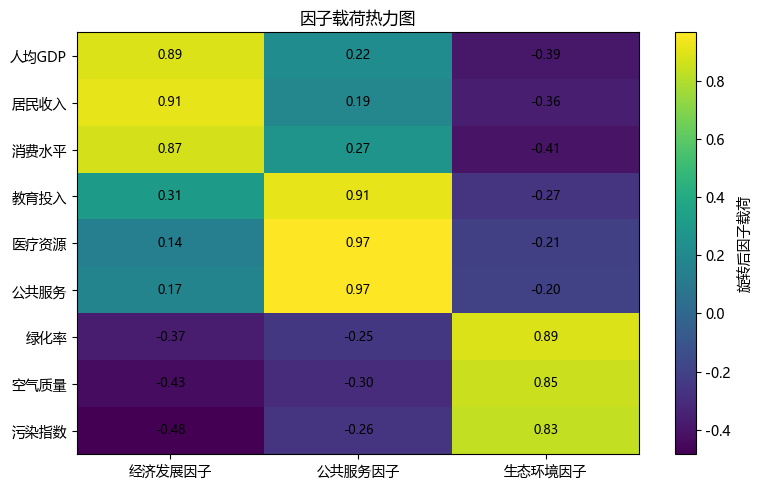

In [11]:
plt.figure(figsize=(8, 5))
plt.imshow(rot_loadings_df.values, aspect='auto')
plt.colorbar(label='旋转后因子载荷')
plt.xticks(range(n_factors), rot_loadings_df.columns)
plt.yticks(range(len(all_cols)), all_cols)
plt.title('因子载荷热力图')
for i in range(len(all_cols)):
    for j in range(n_factors):
        plt.text(j, i, f'{rot_loadings_df.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / '03_因子载荷热力图.png', dpi=180)
plt.show()

### 4.4 公共度与特殊方差

公共度表示某个指标能被公共因子解释的比例：

$$h_i^2=\lambda_{i1}^2+\lambda_{i2}^2+\cdots+\lambda_{im}^2$$

特殊方差表示不能被公共因子解释的部分：

$$\psi_i=1-h_i^2$$

In [12]:
communalities = (rot_loadings ** 2).sum(axis=1)
uniqueness = 1 - communalities
fa_explain = pd.DataFrame({
    '指标': all_cols,
    '公共度': communalities,
    '特殊方差': uniqueness
}).sort_values('公共度', ascending=False)
fa_explain.round(3)

,指标,公共度,特殊方差
5,公共服务,1.0,0.0
4,医疗资源,1.0,0.0
7,空气质量,1.0,0.0
6,绿化率,1.0,0.0
8,污染指数,1.0,0.0
0,人均GDP,1.0,0.0
1,居民收入,1.0,0.0
3,教育投入,1.0,0.0
2,消费水平,1.0,0.0


### 4.5 因子得分与综合得分

每个对象在每个因子上都有一个因子得分。因子得分可以用于解释对象在哪些潜在维度上表现更强。

综合得分可按因子解释能力加权求和。这里为了示范，用旋转载荷平方和近似因子贡献权重。

In [13]:
factor_weight = (rot_loadings ** 2).sum(axis=0)
factor_weight = factor_weight / factor_weight.sum()
fa_score = rot_factor_scores @ factor_weight

factor_score_df = pd.DataFrame(rot_factor_scores, columns=rot_loadings_df.columns)
fa_result = pd.concat([df[['城市']], factor_score_df], axis=1)
fa_result['因子分析综合得分'] = fa_score
fa_result['因子分析排名'] = fa_result['因子分析综合得分'].rank(ascending=False, method='min').astype(int)
fa_result.sort_values('因子分析排名')


,城市,经济发展因子,公共服务因子,生态环境因子,因子分析综合得分,因子分析排名
4,城市E,1.683114,-0.391520,2.154025,1.119820,1
7,城市H,-0.124911,1.724552,0.105922,0.581193,2
10,城市K,-0.066596,0.286300,0.875126,0.349521,3
9,城市J,0.700195,0.738421,-0.464163,0.348314,4
11,城市L,0.676308,-0.387357,0.266750,0.183446,5
2,城市C,0.893480,0.428565,-0.945789,0.157633,6
3,城市D,-1.157529,1.506624,-0.169460,0.065105,7
6,城市G,1.302334,-0.437271,-1.532341,-0.182325,8
5,城市F,-1.303756,0.397712,0.063528,-0.292133,9
8,城市I,-1.038627,-1.461205,0.884710,-0.580541,10


## 5. 模糊综合评价

模糊综合评价适合处理“优秀、良好、一般、较差”等边界不清的等级评价问题。

四个核心要素：

- 因素集：$U=\{u_1,u_2,\dots,u_n\}$；
- 评价集：$V=\{v_1,v_2,\dots,v_m\}$；
- 权重向量：$W=(w_1,w_2,\dots,w_n)$；
- 隶属矩阵：$R=(r_{ij})_{n\times m}$。

核心公式：

$$B=WR$$

其中 $B$ 是综合评价向量。

### 5.1 设计评价等级与隶属度函数

这里设置四个等级：优秀、良好、一般、较差。为了演示，我们使用简化的分段隶属度函数，把标准化指标值转化为对四个等级的隶属度。

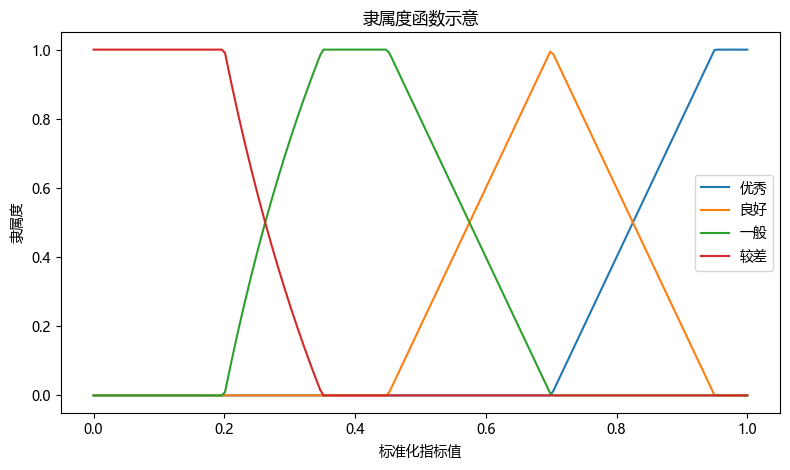

In [14]:
grades = ['优秀', '良好', '一般', '较差']
score_values = np.array([100, 80, 60, 40])

def membership(x):
    # x in [0, 1], higher is better
    excellent = np.clip((x - 0.70) / 0.25, 0, 1)
    good = np.where(x <= 0.45, 0, np.where(x <= 0.70, (x-0.45)/0.25, np.clip((0.95-x)/0.25, 0, 1)))
    medium = np.where(x <= 0.20, 0, np.where(x <= 0.45, (x-0.20)/0.25, np.clip((0.70-x)/0.25, 0, 1)))
    poor = np.clip((0.35 - x) / 0.35, 0, 1)
    vec = np.array([excellent, good, medium, poor], dtype=float)
    if vec.sum() == 0:
        vec[np.argmax([excellent, good, medium, poor])] = 1
    return vec / vec.sum()

xs = np.linspace(0, 1, 200)
ms = np.array([membership(x) for x in xs])
plt.figure(figsize=(8, 4.8))
for i, g in enumerate(grades):
    plt.plot(xs, ms[:, i], label=g)
plt.xlabel('标准化指标值')
plt.ylabel('隶属度')
plt.title('隶属度函数示意')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '04_隶属度函数示意.png', dpi=180)
plt.show()

### 5.2 构造隶属矩阵 $R$

对每个城市而言，每个指标都会得到一个隶属度向量。

如果有 $n$ 个指标、$m$ 个等级，则单个城市的隶属矩阵为：

$$R=\begin{bmatrix}
r_{11}&r_{12}&\cdots&r_{1m}\\
r_{21}&r_{22}&\cdots&r_{2m}\\
\vdots&\vdots&\ddots&\vdots\\
r_{n1}&r_{n2}&\cdots&r_{nm}
\end{bmatrix}$$

In [15]:
# 使用 PCA 贡献信息和因子分析思路可确定权重。这里为了示范，先用熵权思想计算一个客观权重。
P = df_norm[all_cols].values.copy()
P = P / P.sum(axis=0)
eps = 1e-12
e = -(P * np.log(P + eps)).sum(axis=0) / np.log(len(df_norm))
d = 1 - e
weights = d / d.sum()
weight_series = pd.Series(weights, index=all_cols)
weight_series.round(4)

人均GDP    0.1266
居民收入     0.1348
消费水平     0.1198
教育投入     0.0932
医疗资源     0.1057
公共服务     0.1046
绿化率      0.1059
空气质量     0.1073
污染指数     0.1021
dtype: float64

In [16]:
fuzzy_rows = []
for idx, row in df_norm.iterrows():
    R = np.array([membership(row[col]) for col in all_cols])
    B = weights @ R
    fuzzy_score = B @ score_values
    fuzzy_rows.append({
        '城市': row['城市'],
        '优秀隶属度': B[0],
        '良好隶属度': B[1],
        '一般隶属度': B[2],
        '较差隶属度': B[3],
        '模糊综合得分': fuzzy_score,
        '最终等级': grades[int(np.argmax(B))]
    })

fuzzy_result = pd.DataFrame(fuzzy_rows)
fuzzy_result['模糊评价排名'] = fuzzy_result['模糊综合得分'].rank(ascending=False, method='min').astype(int)
fuzzy_result.sort_values('模糊评价排名')

,城市,优秀隶属度,良好隶属度,一般隶属度,较差隶属度,模糊综合得分,最终等级,模糊评价排名
4,城市E,0.237923,0.409550,0.347706,0.004821,77.611526,良好,1
7,城市H,0.303563,0.166970,0.529467,0.000000,75.481932,一般,2
9,城市J,0.264335,0.420299,0.139703,0.175662,75.466131,良好,3
2,城市C,0.346171,0.338463,0.000000,0.315366,74.308797,优秀,4
6,城市G,0.381071,0.162742,0.140821,0.315366,72.190373,优秀,5
3,城市D,0.236001,0.136528,0.512092,0.115379,69.863007,一般,6
10,城市K,0.040050,0.393408,0.566542,0.000000,69.470162,一般,7
11,城市L,0.000000,0.377733,0.622267,0.000000,67.554658,一般,8
5,城市F,0.000000,0.414228,0.204701,0.381071,60.663139,良好,9
8,城市I,0.315366,0.000000,0.000000,0.684634,58.921947,较差,10


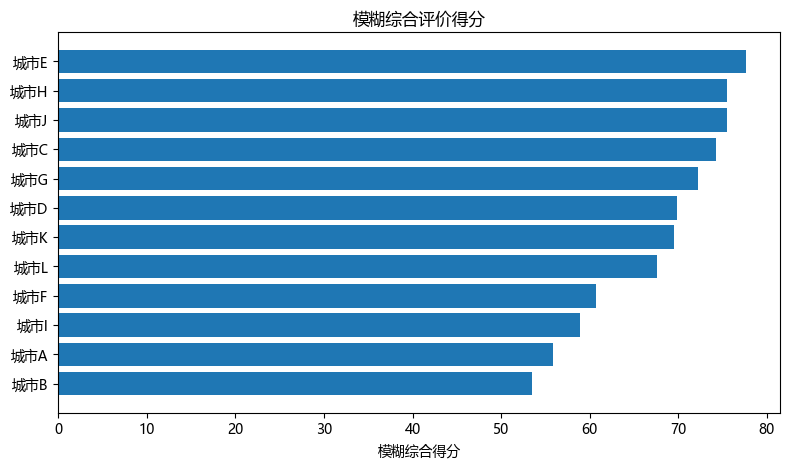

In [17]:
plot_df = fuzzy_result.sort_values('模糊评价排名')
plt.figure(figsize=(8, 4.8))
plt.barh(plot_df['城市'][::-1], plot_df['模糊综合得分'][::-1])
plt.xlabel('模糊综合得分')
plt.title('模糊综合评价得分')
plt.tight_layout()
plt.savefig(OUT_DIR / '05_模糊综合评价得分.png', dpi=180)
plt.show()

## 6. 多模型对比

同一份评价数据可以从不同角度分析：

- 灰色关联：与理想参考序列的接近程度；
- PCA：最大方差信息压缩后的综合表现；
- 因子分析：潜在公共因子结构与因子得分；
- 模糊综合评价：对评价等级的隶属程度与综合等级。

多模型不是为了堆砌，而是为了让不同模型回答不同问题。

In [18]:
summary = gra_result[['城市', '灰色关联度', 'GRA排名']].merge(
    pca_result[['城市', 'PCA综合得分', 'PCA排名']], on='城市'
).merge(
    fa_result[['城市', '因子分析综合得分', '因子分析排名']], on='城市'
).merge(
    fuzzy_result[['城市', '模糊综合得分', '最终等级', '模糊评价排名']], on='城市'
)
summary = summary.sort_values('GRA排名')
summary.to_csv(OUT_DIR / '第5讲_评价模型拓展结果汇总.csv', index=False, encoding='utf-8-sig')
summary.to_excel(OUT_DIR / '第5讲_评价模型拓展结果汇总.xlsx', index=False)
summary

,城市,灰色关联度,GRA排名,PCA综合得分,PCA排名,因子分析综合得分,因子分析排名,模糊综合得分,最终等级,模糊评价排名
0,城市H,0.666073,1,-1.168721,9,0.581193,2,75.481932,一般,2
1,城市G,0.627877,2,-3.380270,12,-0.182325,8,72.190373,优秀,5
2,城市E,0.624484,3,0.797273,5,1.119820,1,77.611526,良好,1
3,城市C,0.616971,4,-2.801733,11,0.157633,6,74.308797,优秀,4
4,城市J,0.610017,5,-2.185171,10,0.348314,4,75.466131,良好,3
5,城市D,0.581247,6,0.075211,6,0.065105,7,69.863007,一般,6
6,城市I,0.555556,7,3.808831,1,-0.580541,10,58.921947,较差,10
7,城市K,0.542070,8,0.965431,4,0.349521,3,69.470162,一般,7
8,城市L,0.519773,9,-0.251591,8,0.183446,5,67.554658,一般,8
9,城市F,0.502538,10,1.524547,3,-0.292133,9,60.663139,良好,9


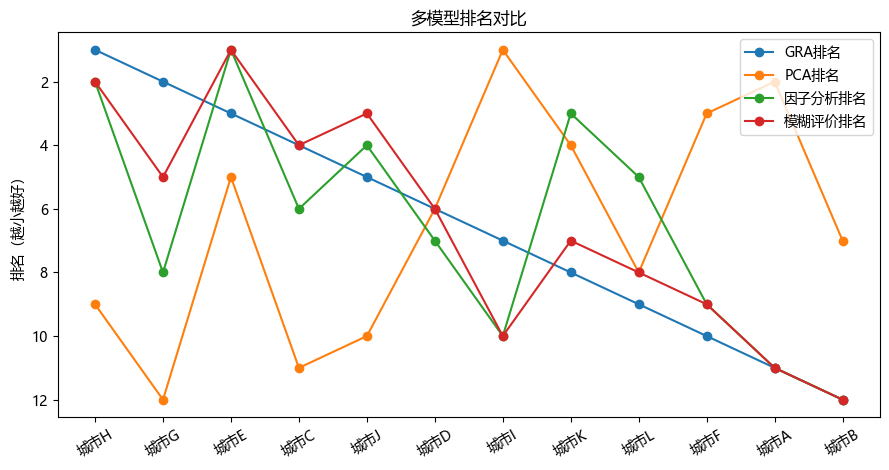

In [19]:
rank_cols = ['GRA排名', 'PCA排名', '因子分析排名', '模糊评价排名']
rank_plot = summary.set_index('城市')[rank_cols]
plt.figure(figsize=(9, 4.8))
for col in rank_cols:
    plt.plot(rank_plot.index, rank_plot[col], marker='o', label=col)
plt.gca().invert_yaxis()
plt.ylabel('排名（越小越好）')
plt.title('多模型排名对比')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '06_多模型排名对比.png', dpi=180)
plt.show()

## 7. 论文写法示例

### 7.1 因子分析写法

> 为进一步解释指标体系背后的潜在结构，本文对标准化后的指标进行因子分析。根据因子载荷矩阵可知，人均 GDP、居民收入和消费水平在因子 1 上载荷较高，因此将因子 1 命名为经济发展因子；教育投入、医疗资源和公共服务在因子 2 上载荷较高，因此将因子 2 命名为公共服务因子；绿化率、空气质量等指标在因子 3 上表现突出，因此将因子 3 命名为生态环境因子。基于各因子得分进一步计算综合得分，从而得到各城市在潜在维度上的综合表现。

### 7.2 模糊综合评价写法

> 为处理评价等级之间的模糊边界，本文构建模糊综合评价模型。首先建立因素集和评价集，并根据标准化指标值构造隶属度矩阵；然后结合客观权重向量计算综合评价向量 $B=WR$；最后根据最大隶属度原则和等级得分化方法得到综合等级和综合得分。结果显示，部分城市对“优秀”等级的隶属度较高，说明其综合发展水平较好；而得分较低城市主要受公共服务和生态环境指标影响，需要进一步改进。

## 课后小作业：比较四类评价模型的排序稳定性

请基于本讲最后得到的 `summary` 表完成下面任务：

1. 计算四类模型排名的平均排名和排名差异范围；
2. 找出排名差异最大的城市；
3. 计算四类排名之间的 Spearman 相关系数；
4. 用一段话解释：评价结论是否稳定，哪些城市需要重点解释。

In [20]:
# 小作业解答
rank_cols = ['GRA排名', 'PCA排名', '因子分析排名', '模糊评价排名']

homework5 = summary[['城市'] + rank_cols].copy()
homework5['平均排名'] = homework5[rank_cols].mean(axis=1)
homework5['排名差异范围'] = homework5[rank_cols].max(axis=1) - homework5[rank_cols].min(axis=1)
homework5 = homework5.sort_values(['平均排名', '排名差异范围']).reset_index(drop=True)

print('四类评价模型的综合排序：')
display(homework5)

rank_corr = summary[rank_cols].corr(method='spearman')
print('四类模型排名的 Spearman 相关系数：')
display(rank_corr.round(3))

max_diff_city = homework5.loc[homework5['排名差异范围'].idxmax()]
avg_corr = rank_corr.where(~np.eye(len(rank_cols), dtype=bool)).stack().mean()

print(f"排名差异最大的城市：{max_diff_city['城市']}，差异范围为 {max_diff_city['排名差异范围']:.0f} 位。") 
print(f"四类模型两两排名相关系数的平均值为：{avg_corr:.3f}。") 

if avg_corr >= 0.8:
    print('结论：四类模型排序较为一致，综合评价结果比较稳定。')
elif avg_corr >= 0.5:
    print('结论：四类模型排序基本一致，但个别城市存在名次差异，需要结合指标结构解释。')
else:
    print('结论：四类模型排序差异较大，应检查指标方向、标准化方法和模型适用性。')

四类评价模型的综合排序：


,城市,GRA排名,PCA排名,因子分析排名,模糊评价排名,平均排名,排名差异范围
0,城市E,3,5,1,1,2.50,4
1,城市H,1,9,2,2,3.50,8
2,城市K,8,4,3,7,5.50,5
3,城市J,5,10,4,3,5.50,7
4,城市D,6,6,7,6,6.25,1
5,城市C,4,11,6,4,6.25,7
6,城市G,2,12,8,5,6.75,10
7,城市I,7,1,10,10,7.00,9
8,城市L,9,8,5,8,7.50,4
9,城市F,10,3,9,9,7.75,7


四类模型排名的 Spearman 相关系数：


,GRA排名,PCA排名,因子分析排名,模糊评价排名
GRA排名,1.000,-0.573,0.657,0.895
PCA排名,-0.573,1.000,-0.315,-0.552
因子分析排名,0.657,-0.315,1.000,0.860
模糊评价排名,0.895,-0.552,0.860,1.000


排名差异最大的城市：城市G，差异范围为 10 位。
四类模型两两排名相关系数的平均值为：0.162。
结论：四类模型排序差异较大，应检查指标方向、标准化方法和模型适用性。
